In [1]:
import os, json

os.chdir(r'C:\Users\zkx14\Desktop\testing')
print('Working directory:', os.getcwd())

with open('splits.json') as f:
    splits = json.load(f)

img_paths_all  = splits['images']
mask_paths_all = splits['masks']

print(f'Loaded {len(img_paths_all)} image-mask pairs')

Working directory: C:\Users\zkx14\Desktop\testing
Loaded 232 image-mask pairs


c:\Users\zkx14\Desktop\testing\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 185 | Val: 47
Using: NVIDIA RTX 2000 Ada Generation


c:\Users\zkx14\Desktop\testing\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\zkx14\.cache\huggingface\hub\models--smp-hub--efficientnet-b4.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
C:\Users\zkx14\AppData\Local\Temp\ipykernel_10708\3335048441.py:96: FutureWarning: `torch.cuda.amp.

Epoch 01/50 | Train Loss: 0.4758 | Val Loss: 0.3036
           ✓ Best model saved (val loss: 0.3036)
Epoch 02/50 | Train Loss: 0.1976 | Val Loss: 0.1512
           ✓ Best model saved (val loss: 0.1512)
Epoch 03/50 | Train Loss: 0.1288 | Val Loss: 0.1119
           ✓ Best model saved (val loss: 0.1119)
Epoch 04/50 | Train Loss: 0.1001 | Val Loss: 0.0921
           ✓ Best model saved (val loss: 0.0921)
Epoch 05/50 | Train Loss: 0.0833 | Val Loss: 0.0757
           ✓ Best model saved (val loss: 0.0757)
Epoch 06/50 | Train Loss: 0.0738 | Val Loss: 0.0695
           ✓ Best model saved (val loss: 0.0695)
Epoch 07/50 | Train Loss: 0.0662 | Val Loss: 0.0637
           ✓ Best model saved (val loss: 0.0637)
Epoch 08/50 | Train Loss: 0.0606 | Val Loss: 0.0584
           ✓ Best model saved (val loss: 0.0584)
Epoch 09/50 | Train Loss: 0.0576 | Val Loss: 0.0537
           ✓ Best model saved (val loss: 0.0537)
Epoch 10/50 | Train Loss: 0.0550 | Val Loss: 0.0519
           ✓ Best model saved (val loss

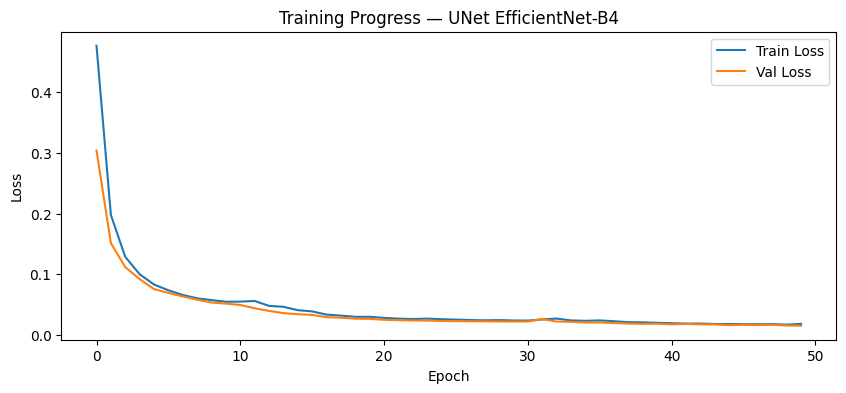


Done! Best val loss: 0.0156
Model  -> models/unet_efficientb4.pth


In [ ]:
# Dental X-ray mandible segmentation
# U-Net with EfficientNet-B4 backbone + combined Dice-BCE loss

import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Custom Dataset
class DentalDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.transform  = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img  = cv2.imread(str(self.img_paths[idx]))
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(self.mask_paths[idx]), 0)
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']

        return img, mask.unsqueeze(0)


# Transforms — added CLAHE and RandomGamma for X-ray contrast
train_transform = A.Compose([
    A.Resize(512, 1024),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussianBlur(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.4),
    A.CLAHE(clip_limit=4.0, p=0.3),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(512, 1024),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


# Train / Validation Split
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    img_paths_all, mask_paths_all,
    test_size=0.2, random_state=42          # same seed = same split as resnet50
)
print(f'Train: {len(train_imgs)} | Val: {len(val_imgs)}')


# DataLoaders — batch_size 4 because efficientnet-b4 is larger
train_ds = DentalDataset(train_imgs, train_masks, train_transform)
val_ds   = DentalDataset(val_imgs,   val_masks,   val_transform)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=0, pin_memory=True)


# Model — EfficientNet-B4 encoder, logits output (no sigmoid inside model)
device = torch.device('cuda')
print(f'Using: {torch.cuda.get_device_name(0)}')

model = smp.Unet(
    encoder_name='efficientnet-b4',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None                         # logits — loss handles sigmoid internally
).to(device)


# Combined Dice + BCE loss — better than pure Dice for class imbalance
dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)
bce_loss  = smp.losses.SoftBCEWithLogitsLoss()

def loss_fn(preds, masks):
    return 0.5 * dice_loss(preds, masks) + 0.5 * bce_loss(preds, masks)


# Cosine annealing — explores loss landscape better than ReduceLROnPlateau
scaler    = torch.cuda.amp.GradScaler()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)


# Training loop
best_val_loss = float('inf')
train_losses  = []
val_losses    = []

for epoch in range(50):

    # Train
    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        with torch.cuda.amp.autocast():
            preds = model(imgs)
            loss  = loss_fn(preds, masks)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    # Validate
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            with torch.cuda.amp.autocast():
                preds     = model(imgs)
                val_loss += loss_fn(preds, masks).item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(epoch)

    print(f'Epoch {epoch+1:02d}/50 | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'models/unet_efficientb4.pth')
        print(f'Best model saved (val loss: {best_val_loss:.4f})')


# Loss curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress — UNet EfficientNet-B4')
plt.legend()
plt.show()

print(f'\nDone! Best val loss: {best_val_loss:.4f}')